In [4]:
def visualize_ontology(ontology):
    import json
    import networkx as nx
    import matplotlib.pyplot as plt

    """
    Visualize the ontology schema using matplotlib.
    """
    pos = nx.spring_layout(ontology)
    plt.figure(figsize=(12, 8))

    # Draw nodes and edges
    nx.draw(
        ontology, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold"
    )

    # Add edge labels
    edge_labels = nx.get_edge_attributes(ontology, 'relation')
    nx.draw_networkx_edge_labels(ontology, pos, edge_labels=edge_labels, font_size=9)

    plt.title("Ontology Schema Visualization", fontsize=16)
    plt.show()

In [9]:
def create_ontology():
    ontology = nx.DiGraph()

    # Define classes and their attributes
    classes = {
        "Product": ["id", "name", "price", "category"],
        "Order": ["id", "product_id", "quantity", "total_price"],
        "Customer": ["id", "name", "email", "loyalty_points"],
    }

    # Add classes and attributes to the graph
    for cls, attributes in classes.items():
        ontology.add_node(cls, type="class")
        for attr in attributes:
            ontology.add_node(f"{cls}.{attr}", type="attribute")
            ontology.add_edge(cls, f"{cls}.{attr}", relation="has_attribute")

    return ontology

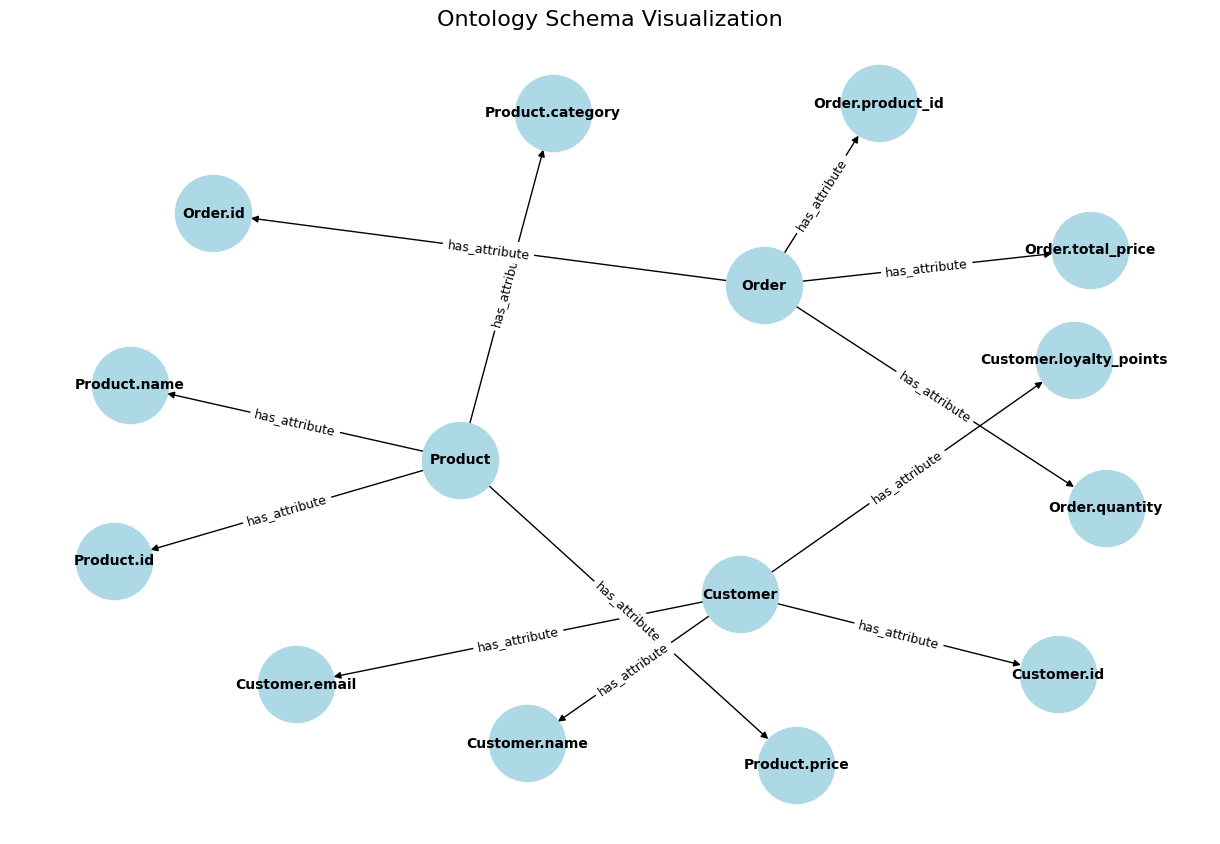

In [11]:
import json
import networkx as nx
import matplotlib.pyplot as plt

ontology = create_ontology()
visualize_ontology(ontology)

In [13]:
# !pip install boto3 matplotlib networkx
# !pip install streamlit
import sys
print(sys.executable)


c:\Users\rajes\anaconda3\envs\new_env\python.exe


In [ ]:

import json
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Create the ontology schema using NetworkX
def create_ontology():
    ontology = nx.DiGraph()

    # Define classes and their attributes
    classes = {
        "Product": ["id", "name", "price", "category"],
        "Order": ["id", "product_id", "quantity", "total_price"],
        "Customer": ["id", "name", "email", "loyalty_points"],
    }

    # Add classes and attributes to the graph
    for cls, attributes in classes.items():
        ontology.add_node(cls, type="class")
        for attr in attributes:
            ontology.add_node(f"{cls}.{attr}", type="attribute")
            ontology.add_edge(cls, f"{cls}.{attr}", relation="has_attribute")

    return ontology

ontology = create_ontology()

# Step 2: Sample rules
rules = [
    {
        "rule_id": "R1",
        "description": "Discount rule for products in category 'Electronics'.",
        "conditions": [
            {"attribute": "Product.category", "operator": "equals", "value": "Electronics"},
            {"attribute": "Product.price", "operator": "greater_than", "value": 1000}
        ],
        "actions": [
            {"attribute": "Product.price", "operation": "multiply", "value": 0.9}
        ]
    },
    {
        "rule_id": "R2",
        "description": "Add loyalty points for customers on orders over $500.",
        "conditions": [
            {"attribute": "Order.total_price", "operator": "greater_than", "value": 500}
        ],
        "actions": [
            {"attribute": "Customer.loyalty_points", "operation": "add", "value": 50}
        ]
    }
]

# Step 3: Lambda function for rule execution
def evaluate_conditions(conditions, data):
    """
    Evaluate if all conditions are satisfied for the given data.
    """
    for condition in conditions:
        attribute = condition["attribute"]
        operator = condition["operator"]
        value = condition["value"]

        # Resolve nested attributes (e.g., "Product.price")
        keys = attribute.split('.')
        current_value = data
        for key in keys:
            current_value = current_value.get(key)

        # Perform condition evaluation
        if operator == "equals" and current_value != value:
            return False
        elif operator == "not_equals" and current_value == value:
            return False
        elif operator == "greater_than" and not (current_value > value):
            return False
        elif operator == "less_than" and not (current_value < value):
            return False
        elif operator == "in" and current_value not in value:
            return False
        elif operator == "not_in" and current_value in value:
            return False
        elif operator == "between" and not (value[0] <= current_value <= value[1]):
            return False

    return True

def apply_actions(actions, data):
    """
    Apply the actions to the data object.
    """
    for action in actions:
        attribute = action["attribute"]
        operation = action["operation"]
        value = action["value"]

        # Resolve nested attributes (e.g., "Product.price")
        keys = attribute.split('.')
        current = data
        for key in keys[:-1]:
            current = current.get(key)
        final_key = keys[-1]

        # Perform the action
        if operation == "add":
            current[final_key] += value
        elif operation == "multiply":
            current[final_key] *= value

    return data

def lambda_handler(event, context):
    """
    AWS Lambda function to execute rules on input data.
    """
    try:
        rules = event.get("rules", [])
        data = event.get("data", {})

        results = []

        for rule in rules:
            conditions = rule["conditions"]
            actions = rule["actions"]

            if evaluate_conditions(conditions, data):
                data = apply_actions(actions, data)
                results.append({"rule_id": rule["rule_id"], "executed": True})
            else:
                results.append({"rule_id": rule["rule_id"], "executed": False})

        return {
            "statusCode": 200,
            "body": json.dumps({
                "results": results,
                "modified_data": data
            })
        }

    except Exception as e:
        return {
            "statusCode": 500,
            "body": json.dumps({"error": str(e)})
        }

# Step 4: Visualize the ontology
def visualize_ontology(ontology):
    """
    Visualize the ontology schema using matplotlib.
    """
    pos = nx.spring_layout(ontology)
    plt.figure(figsize=(12, 8))

    # Draw nodes and edges
    nx.draw(
        ontology, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold"
    )

    # Add edge labels
    edge_labels = nx.get_edge_attributes(ontology, 'relation')
    nx.draw_networkx_edge_labels(ontology, pos, edge_labels=edge_labels, font_size=9)

    plt.title("Ontology Schema Visualization", fontsize=16)
    plt.show()

# Example Input for Local Testing
data_example = {
    "Product": {
        "id": "P123",
        "name": "Smartphone",
        "price": 1200,
        "category": "Electronics"
    },
    "Order": {
        "id": "O456",
        "product_id": "P123",
        "quantity": 1,
        "total_price": 1200
    },
    "Customer": {
        "id": "C789",
        "name": "John Doe",
        "email": "john.doe@example.com",
        "loyalty_points": 100
    }
}

# Simulate Lambda Invocation
event_example = {
    "rules": rules,
    "data": data_example
}

if __name__ == "__main__":
    # Visualize the ontology
    visualize_ontology(ontology)

    # Test the Lambda function
    response = lambda_handler(event_example, None)
    print(json.dumps(response, indent=4))


In [1]:
!pip install streamlit
